# Import các class

In [1]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.data_handler import DataHandler
from utils.ml_models import SentimentModel
from utils.visualizer import ModelVisualizer

# Xử lý lại dạng txt ra csv 

In [2]:
input_txt = 'train.txt'  
output_csv = 'result.csv'

with open(input_txt, 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]
lines=lines[1:]

with open(output_csv, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f, quoting=csv.QUOTE_MINIMAL)
    f.write("STT,class,text\n")    
    for i, line in enumerate(lines):
        parts = line.split(',', 2) 
        if len(parts) == 3:
            STT=parts[0]
            label = parts[1]
            content = parts[2]
            writer.writerow([STT, label, content])

print(f"Đã lưu file {output_csv} xong!")

Đã lưu file result.csv xong!


# EDA


1. Thông tin tổng quan của dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   STT     1224 non-null   int64 
 1   class   1224 non-null   object
 2   text    1224 non-null   object
dtypes: int64(1), object(2)
memory usage: 28.8+ KB
None

2. Kiểm tra dữ liệu bị thiếu (Missing values):
STT      0
class    0
text     0
dtype: int64


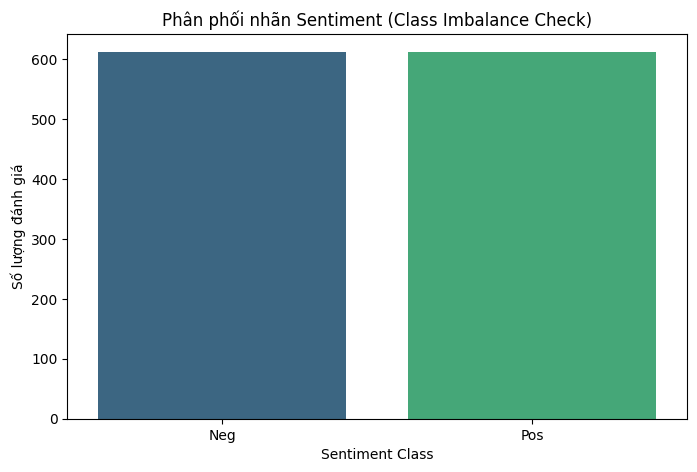

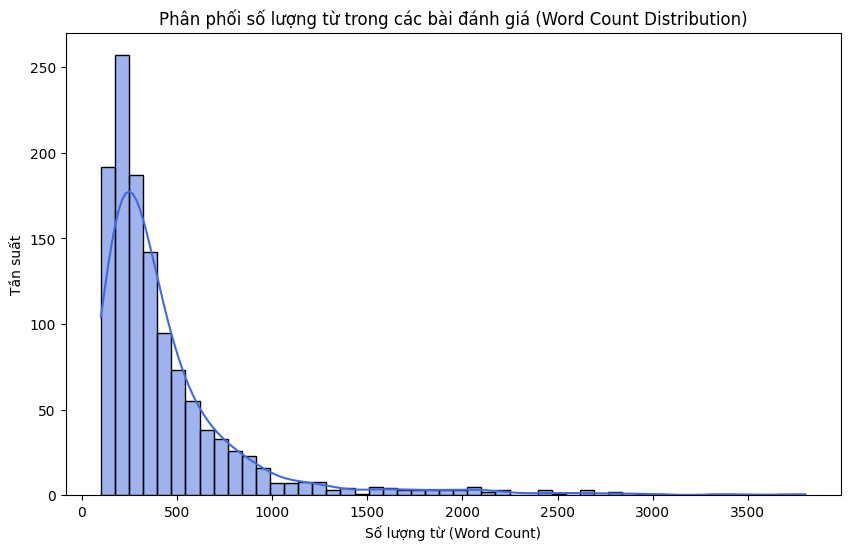


3. Thống kê độ dài văn bản:
count    1224.000000
mean      451.842320
std       442.322541
min       101.000000
25%       208.000000
50%       310.500000
75%       506.000000
max      3802.000000
Name: word_count, dtype: float64


In [3]:
df = pd.read_csv(output_csv)

# 2.1. Thông tin cơ bản
print("\n1. Thông tin tổng quan của dataset:")
print(df.info())
print("\n2. Kiểm tra dữ liệu bị thiếu (Missing values):")
print(df.isnull().sum())

df = df.dropna(subset=['text'])

# 2.2. Kiểm tra phân phối nhãn (Class Distribution)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class', hue='class', palette='viridis', order=df['class'].value_counts().index, legend=False)
plt.title('Phân phối nhãn Sentiment (Class Imbalance Check)')
plt.xlabel('Sentiment Class')
plt.ylabel('Số lượng đánh giá')
plt.show()

# 2.3. Phân phối độ dài văn bản (Text Length Distribution)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', bins=50, kde=True, color='royalblue')
plt.title('Phân phối số lượng từ trong các bài đánh giá (Word Count Distribution)')
plt.xlabel('Số lượng từ (Word Count)')
plt.ylabel('Tần suất')
plt.show()

print(f"\n3. Thống kê độ dài văn bản:")
print(df['word_count'].describe())

# Chia data train/test

In [4]:
data = DataHandler('result.csv')
X_train, X_test, y_train, y_test = data.load_and_split()
X_train_vec, X_test_vec = data.vectorize_data(X_train, X_test)

trainer = SentimentModel()

---
# Part 1: Sentiment Analysis 
## 1. Chạy thử Logistic Regression

Saved 'Logistic Regression' at 'logistic_model.pkl'
Accuracy: 0.8490



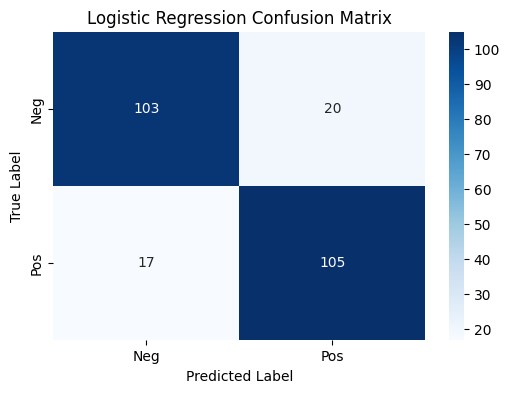

In [5]:
model_lr, y_pred_lr, acc_lr, report_lr = trainer.train_and_evaluate(
    model_name='Logistic Regression',
    X_train_vec=X_train_vec, 
    y_train=y_train, 
    X_test_vec=X_test_vec, 
    y_test=y_test,
    vectorizer=data.vectorizer,  # Phải truyền vectorizer vào để save
    save_model=True,             # Lựa chọn bật/tắt việc lưu file
    filepath="logistic_model.pkl"
)
print(f"Accuracy: {acc_lr:.4f}\n")

ModelVisualizer.plot_confusion_matrix(y_test, y_pred_lr, title="Logistic Regression Confusion Matrix")

In [12]:
pred, prob = SentimentModel.predict_single_text("This car is absolutely beautiful and runs smoothly!", "logistic_model.pkl")
print(f"Inference kết quả: {pred} | Xác suất: {prob}\n")

Inference kết quả: Pos | Xác suất: {'Neg': np.float64(0.3994156982753697), 'Pos': np.float64(0.6005843017246303)}



## 2. Chạy thử SVM

Accuracy: 0.8327



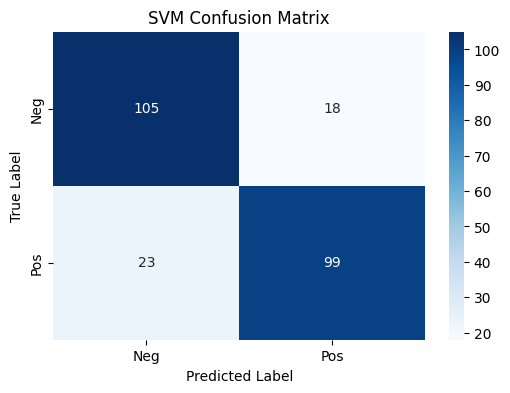

In [13]:
model_svm, y_pred_svm, acc_svm, report_svm = trainer.train_and_evaluate(
    model_name='SVM',
    X_train_vec=X_train_vec, 
    y_train=y_train, 
    X_test_vec=X_test_vec, 
    y_test=y_test,
)
print(f"Accuracy: {acc_svm:.4f}\n")

ModelVisualizer.plot_confusion_matrix(y_test, y_pred_svm, title="SVM Confusion Matrix")

# 3. Nếu muốn update thuật toán thì chỉ cần import rồi tạo dictionary thì class sẽ có thêm các thuật toán ML mới (naive bayes không có sẵn trong class ml_models.py)

Processing algorithm: Model LogReg...
Processing algorithm: Model SVM...
Processing algorithm: Model Naive Bayes...


,Model,Accuracy
0,Model LogReg,0.848980
1,Model Naive Bayes,0.836735
2,Model SVM,0.832653


c:\Project\ML-LLM\utils\visualizer.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_results, palette='viridis')


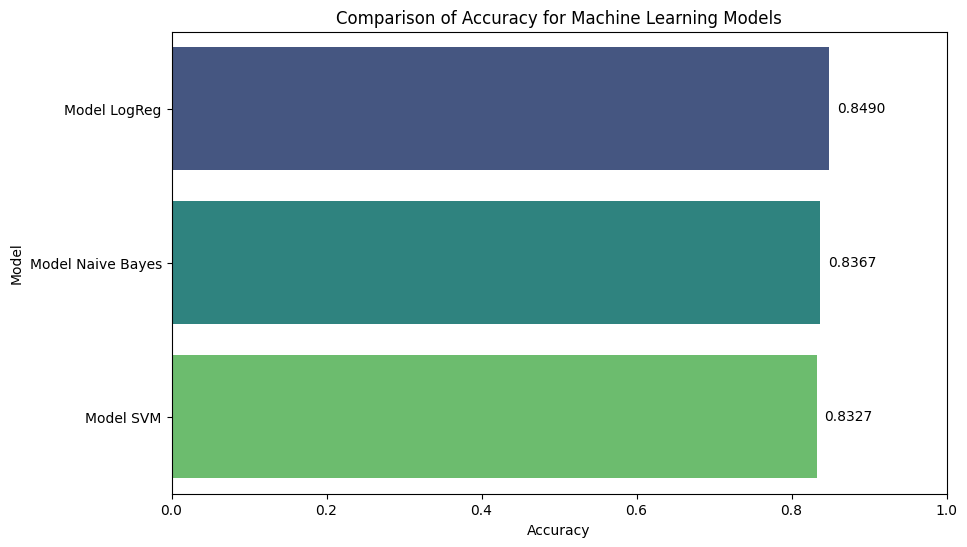

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from utils.ml_models import ModelComparator

# Initialize a dictionary containing the algorithms to "compete"
my_models = {
    'Model LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'Model SVM': LinearSVC(max_iter=1000, random_state=42),
    'Model Naive Bayes': MultinomialNB() 
}

comparator = ModelComparator(models_to_compare=my_models)
df_compare = comparator.compare(X_train_vec, y_train, X_test_vec, y_test)

display(df_compare)
ModelVisualizer.plot_model_comparison(df_compare)

## 4. Thử dùng LLM

In [8]:
from utils.llm_models import LLMSentimentAnalyzer

llm_analyzer = LLMSentimentAnalyzer(model_name="llama3.2:3b")

test_sentence = "The transmission is clunky, but overall the seats are comfortable. Not sure if I would buy it again."

print("Zero-shot prediction:", llm_analyzer.predict_zero_shot(test_sentence))
print("Few-shot prediction:", llm_analyzer.predict_few_shot(test_sentence))

y_pred_zero, acc_zero, report_zero = llm_analyzer.evaluate_dataset(X_test, y_test, strategy="zero_shot", batch_mode="parallel", max_workers=4)
print(f"\nAccuracy LLM Zero-shot: {acc_zero:.4f}")

y_pred_few, acc_few, report_few = llm_analyzer.evaluate_dataset(X_test, y_test, strategy="few_shot", batch_mode="parallel", max_workers=4)
print(f"Accuracy LLM Few-shot: {acc_few:.4f}")

c:\Project\ML-LLM\ml_llm_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Đang khởi tạo kết nối với Ollama model: llama3.2:3b...


c:\Project\ML-LLM\utils\llm_models.py:15: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaLLM``.
  self.llm = Ollama(model=model_name, temperature=temperature)


Zero-shot prediction: Neg
Few-shot prediction: Pos
Đang chạy LLM inference: Chiến lược=zero_shot | Chế độ=parallel...


Predicting (Parallel): 100%|██████████| 245/245 [12:11<00:00,  2.99s/it]



Accuracy LLM Zero-shot: 0.9265
Đang chạy LLM inference: Chiến lược=few_shot | Chế độ=parallel...


Predicting (Parallel): 100%|██████████| 245/245 [22:36<00:00,  5.54s/it]

Accuracy LLM Few-shot: 0.9184


---
# Part 2: Topic Extraction

In [ ]:
from utils.topic.ml_extractor import MLTopicExtractor
from utils.topic.llm_extractor import DirectPromptingExtractor
from gensim.corpora.dictionary import Dictionary

c:\Project\ML-LLM\ml_llm_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Approach 1 — Machine Learning: NMF

In [16]:
analyzer = data.vectorizer.build_analyzer()
texts_tokenized = [analyzer(text) for text in X_train]
dictionary = Dictionary(texts_tokenized)
feature_names = data.vectorizer.get_feature_names_out()

extractor = MLTopicExtractor(k_min=2, k_max=8)
optimal_k, best_score = extractor.find_optimal_k(
    X_train_vec, texts_tokenized, dictionary, feature_names
)

print(f"Optimal k: {optimal_k} | Coherence Score: {best_score:.4f}")
print("\n1. Top Keywords per Topic:")
display(extractor.get_topics(feature_names))

stats, detail_df = extractor.summarize_results(X_train_vec, X_train)
print("\n2. Topic Distribution Statistics:")
display(stats)

Optimal k: 4 | Coherence Score: 0.6717

1. Top Keywords per Topic:


,Topic 1,Topic 2,Topic 3,Topic 4
0,car,truck,van,explorer
1,mustang,ranger,windstar,vehicle
2,like,quot,miles,suv
3,quot,cab,ford,expedition
4,cars,150,000,seat
5,escort,trucks,transmission,seats
6,good,like,problems,rear
7,ford,bed,000 miles,ford explorer
8,great,ford,replaced,ford
9,taurus,ford ranger,warranty,like



2. Topic Distribution Statistics:


,Count,Percentage (%)
Dominant_Topic,,
1,360,36.77
2,136,13.89
3,254,25.94
4,229,23.39


## Approach 2 — LLM: Direct Prompting

### Approach 1: Direct Prompting 

In [10]:
texts_list = df["text"].astype(str).tolist()

# Config
SAMPLE_SIZE    = 100
BATCH_SIZE     = 5
MAX_WORKERS    = 4
N_FINAL_TOPICS = 4
MODEL_NAME     = "llama3.2:3b"

# Run
extractor = DirectPromptingExtractor(model_name=MODEL_NAME, temperature=0.0)

raw_aspects = extractor.extract_initial_aspects(
    texts_list[:SAMPLE_SIZE],
    batch_size=BATCH_SIZE,
    max_workers=MAX_WORKERS,
)

print(f"\n Raw aspects found : {len(raw_aspects)}")
print(f"   Top 20            : {raw_aspects[:20]}")

final_topics = extractor.refine_topics(raw_aspects, n_final_topics=N_FINAL_TOPICS)

print("\n--- Direct Prompting Topics ---")
for i, topic in enumerate(final_topics, 1):
    print(f"  {i}. {topic}")

Extracting aspects (20 batches, 4 workers)…


100%|██████████| 20/20 [00:22<00:00,  1.15s/it]



 Raw aspects found : 27
   Top 20            : ['Ford', 'Explorer', 'Taurus', 'Expedition', 'Suv', 'Truck', 'Suburban', 'Tempo', 'Transmission', 'Excursion', 'Gas', 'Size', 'Brakes', 'Rotors', 'Police Interceptor', 'Mustang', 'Convertible', 'Reliability', '1997', 'Sho']

--- Direct Prompting Topics ---
  1. Ford Performance
  2. SUV and Truck Reliability
  3. Classic Car Quality
  4. Luxury Vehicle Features


### Approach 2: Embedding-based Clustering

In [12]:
from utils.topic.llm_extractor import EmbeddingClusteringExtractor
EMBED_MODEL    = "all-MiniLM-L6-v2"
LLM_MODEL      = "llama3.2:3b"
N_CLUSTERS     = 4
SAMPLE_PER_CLU = 5

extractor = EmbeddingClusteringExtractor(
    n_clusters         = N_CLUSTERS,
    embed_model        = EMBED_MODEL,
    llm_model          = LLM_MODEL,
    sample_per_cluster = SAMPLE_PER_CLU,
    max_workers        = MAX_WORKERS,
)

extractor.fit(texts_list[:SAMPLE_SIZE])

print("\n--- Topic distribution ---")
for topic, count in extractor.topic_summary().items():
    bar = "█" * (count * 30 // SAMPLE_SIZE)
    print(f"  {topic:<30} {bar} ({count})")

results_df = extractor.get_results(texts_list[:SAMPLE_SIZE])
results_df.to_csv("topic_results.csv", index=False)
print("\nSaved → topic_results.csv")

Loading embedding model 'all-MiniLM-L6-v2'…


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7875.98it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 2/2 [00:00<00:00,  2.86it/s]


Clustering 100 embeddings into 4 clusters…
Naming 4 clusters via LLM (4 workers)…


Naming clusters: 100%|██████████| 4/4 [00:04<00:00,  1.07s/it]


--- Topic distribution ---
  Used Ford Reviews              ███████████ (39)
  Ford Explorer Reviews          ████████ (29)
  Car Review Chaos               ██████ (20)
  Car Buying Experiences         ███ (12)

Saved → topic_results.csv
